In [2]:
import re
import json
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,/;q=0.8",
    "Referer": "https://www.google.com/"
}

In [8]:
#maincode
brand =[]
prices =[] 
processor = []
RAM = []
SSD = []
display = []
discount = []
rating =[]
for i in range(1,94):
    url = f"https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}"
    page = requests.get(url, headers = headers)
    soup = BeautifulSoup(page.text)
    b = soup.find_all("div" , class_ = "RG5Slk")
    for i in b:
        a = i.text.split()
        if a:
            brand.append(a[0])
        else:
            brand.append(np.nan)
    pr = soup.find_all("div" , class_ = "hZ3P6w DeU9vF")
    for i in pr:
        a = i.text
        regex = re.sub(r"[₹,]" , "" , a)
        if regex:
            prices.append(regex)
        else:
            prices.append(np.nan)
    
    features = soup.find_all("div",  class_ = "CMXw7N")
    for i in features:
        a = i.text
        regex = re.findall(r"(Intel.*?|AMD.*?|Snapdragon.*?|MediaTek.*?|Apple.*?)\sProcessor", a)
        if regex:
            processor.append(regex[0].strip())
        else:
            processor.append(np.nan)
    for i in features:
        a = i.text
        regex = re.findall(r"(\d+\s)GB.+?RAM", a)
        if regex:
            RAM.append(regex[0].strip())
        else:
            RAM.append(np.nan)
    for i in features:
        a = i.text
        regex = regex = re.findall(r"(\d+\s(?:GB|TB))\sSSD", a)
        if regex:
            ssd = regex[0].strip()
            if "TB" in ssd:
                SSD.append(int(float(ssd.replace(" TB", "")) * 1024))
            else:
                SSD.append(int(ssd.replace(" GB", "")))
        else:
            SSD.append(np.nan)
    for i in features:
        a = i.text
        regex  = re.findall(r"\(([\d.]+)\s*[Ii]nch",a)
        if regex:
            display.append(regex[0].strip())
        else:
            display.append(np.nan)
    products = soup.find_all("div", class_="jIjQ8S")
    for product in products:
        dis = product.find("div", class_="HQe8jr")
        if dis:
            discount.append(dis.text.replace("% off", ""))
        else:
            discount.append(np.nan)
    for product in products:
        r = product.find("div", class_="MKiFS6")
        if r:
            rating.append(r.text)
        else:
            rating.append(np.nan)
    
        
    
    

In [9]:
print(len(brand))
print(len(prices)) 
print(len(processor))
print(len(RAM))
print(len(SSD))
print(len(display))
print(len(discount))
print(len(rating))

984
984
984
984
984
984
984
984


In [32]:
for i in range(1,94):
    url = f"https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}"
    page = requests.get(url, headers = headers)
    soup = BeautifulSoup(page.text)
    features = soup.find_all("div",  class_ = "CMXw7N")
    for i in features:
        a = i.text
        if "250 nits Narrow BorderIntel" in a:
            print(a)
        

Processor: Intel i5-1235U (Base- 3.30 GHz & Turbo up to 4.40 GHz) 10 CoresRAM & Storage: 8GB DDR4 & 512GB SSDGraphics & Keyboard: Integrated & Standard KeyboardDisplay: 15.6" FHD WVA AG 120Hz 250 nits Narrow BorderIntel Core i5 Processor (12th Gen)8 GB DDR4 RAM64 bit Windows 11 Operating System512 GB SSD38.0 cm (14.96 Inch) Display1 Year Onsite Hardware Service
Processor: Intel i3-1215U (Base- 0.9 GHz & Turbo up to 4.40 GHz) 6 CoresRAM & Storage: 8GB DDR4 & 512GB SSDGraphics & Keyboard: Integrated & Standard KeyboardDisplay: 15.6" FHD WVA AG 120Hz 250 nits Narrow BorderIntel Core i3 Processor (12th Gen)8 GB DDR4 RAM64 bit Windows 11 Operating System512 GB SSD39.37 cm (15.5 Inch) Display1 Year Onsite Hardware Service


for i in range(1,94):
    url = f"https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}"
    page = requests.get(url, headers = headers)
    soup = BeautifulSoup(page.text)
    features = soup.find_all("div",  class_ = "CMXw7N")
    for i in features:
        a = i.text
        if "250 nits Narrow BorderIntel" in a:
            print(a)
        

In [10]:
data = {"Brand" : brand , "Prices":prices , "Processor":processor , "RAM":RAM , "SSD":SSD , "display":display , "discount":discount , "rating":rating} 

In [11]:
df=pd.DataFrame(data)

In [12]:
df.to_csv("laptops.csv")


In [13]:
data = pd.read_csv("laptops.csv")
data.drop("Unnamed: 0",axis=1,inplace=True)

In [16]:
data["discount"] = data["discount"].fillna(data["discount"].median())
data["SSD"] = data["SSD"].fillna(data["SSD"].median())
data["SSD"] = data["SSD"].astype(int)
data["rating"] = data["rating"].fillna(data["rating"].median())
data["display"] = data["display"].fillna(data["display"].mean())

In [17]:
data["Processor"] = data["Processor"].replace({
    "Intel Evo platform feat 11th Gen Intel Core i5 processorIntel Core i5": "Intel Core i5",
    "Snapdragon Snapdragon X Elite": "Snapdragon X Elite",
    "Intel Snapdragon X": "Snapdragon X",
    "MediaTek MediaTek Kompanio 528": "MediaTek Kompanio 528",
    "MediaTek MediaTek Kompanio 540": "MediaTek Kompanio 540",
    "MediaTek MediaTek Kompanio 838": "MediaTek Kompanio 838",
    "AMD Ryzen 5": "AMD Ryzen 5 Hexa Core",
    "AMD Ryzen 7": "AMD Ryzen 7 Octa Core",
})
    

In [18]:
data["Processor"] = data["Processor"].replace(
    r'.*Processor:\s*Intel i5-1235U.*Intel Core i5 Processor.*',
    'Intel Core i5',
    regex=True
)

In [19]:
data["Processor"] = data["Processor"].replace(
    r'.*Processor:\s*Intel i3-1235U.*Intel Core i3 Processor.*',
    'Intel Core i3',
    regex=True
)

In [20]:
data.dtypes

Brand         object
Prices         int64
Processor     object
RAM            int64
SSD            int64
display      float64
discount     float64
rating       float64
dtype: object

In [21]:
data

,Brand,Prices,Processor,RAM,SSD,display,discount,rating
0,Samsung,55311,Intel Core i5,8,512,15.6,29.0,4.4
1,Samsung,72990,Snapdragon X,16,512,15.6,20.0,4.4
2,Acer,59990,Intel Core 5,16,512,15.6,24.0,4.5
3,Neopticon,21990,Intel Celeron Dual Core,4,256,14.1,31.0,3.6
4,Acer,39938,Intel Pentium Quad Core,12,512,15.6,15.0,3.9
...,...,...,...,...,...,...,...,...
979,DELL,197345,Intel Core Ultra 7,16,1024,16.0,17.0,4.3
980,ASUS,169564,Intel Core Ultra 7,32,1024,14.0,7.0,4.6
981,HP,84569,AMD Ryzen 5 Hexa Core,16,512,15.6,6.0,4.3
982,Acer,73199,Intel Core i5,8,512,15.6,17.0,3.9


In [22]:
data.isnull().sum()

Brand        0
Prices       0
Processor    0
RAM          0
SSD          0
display      0
discount     0
rating       0
dtype: int64

In [23]:
data.isnull().sum()/len(df)*100

Brand        0.0
Prices       0.0
Processor    0.0
RAM          0.0
SSD          0.0
display      0.0
discount     0.0
rating       0.0
dtype: float64

In [24]:
data.duplicated().sum()

np.int64(379)

In [25]:
data = data.drop_duplicates()

In [26]:
data.duplicated().sum()

np.int64(0)

In [28]:
data.count()

Brand        605
Prices       605
Processor    605
RAM          605
SSD          605
display      605
discount     605
rating       605
dtype: int64

In [29]:
def rating_flag(rating):
    if rating >= 4.5:
        return "Excellent"
    elif rating >= 4:
        return "Good"
    else:
        return "Average"

data["RatingFlag"] = data["rating"].apply(rating_flag)

C:\Users\DELL\AppData\Local\Temp\ipykernel_23280\3491647039.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["RatingFlag"] = data["rating"].apply(rating_flag)


In [30]:
def category(price):
    if price < 50000:
        return "Affordable"
    elif price < 100000:
        return "Mid-range"
    else:
        return "Premium"

data["PriceCategory"] = data["Prices"].apply(category)

C:\Users\DELL\AppData\Local\Temp\ipykernel_23280\3135036876.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["PriceCategory"] = data["Prices"].apply(category)


In [31]:
def discount_type(d):
    if d == 0:
        return "No Discount"
    elif d <= 20:
        return "Low Discount"
    else:
        return "High Discount"

data["DiscountCategory"] = data["discount"].apply(discount_type)


C:\Users\DELL\AppData\Local\Temp\ipykernel_23280\192772417.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["DiscountCategory"] = data["discount"].apply(discount_type)


In [32]:
data

,Brand,Prices,Processor,RAM,SSD,display,discount,rating,RatingFlag,PriceCategory,DiscountCategory
0,Samsung,55311,Intel Core i5,8,512,15.6,29.0,4.4,Good,Mid-range,High Discount
1,Samsung,72990,Snapdragon X,16,512,15.6,20.0,4.4,Good,Mid-range,Low Discount
2,Acer,59990,Intel Core 5,16,512,15.6,24.0,4.5,Excellent,Mid-range,High Discount
3,Neopticon,21990,Intel Celeron Dual Core,4,256,14.1,31.0,3.6,Average,Affordable,High Discount
4,Acer,39938,Intel Pentium Quad Core,12,512,15.6,15.0,3.9,Average,Affordable,Low Discount
...,...,...,...,...,...,...,...,...,...,...,...
978,Acer,39361,Intel Celeron Dual Core,12,256,14.0,33.0,4.3,Good,Affordable,High Discount
979,DELL,197345,Intel Core Ultra 7,16,1024,16.0,17.0,4.3,Good,Premium,Low Discount
981,HP,84569,AMD Ryzen 5 Hexa Core,16,512,15.6,6.0,4.3,Good,Mid-range,Low Discount
982,Acer,73199,Intel Core i5,8,512,15.6,17.0,3.9,Average,Mid-range,Low Discount


In [33]:
data.to_csv("laptopscleandata.csv")

In [34]:
cleandata = pd.read_csv("laptopscleandata.csv")
cleandata.drop("Unnamed: 0",axis=1,inplace=True)

In [71]:
cleandata

,Brand,Prices,Processor,RAM,SSD,display,discount,rating,RatingFlag,PriceCategory,DiscountCategory
0,Samsung,55311,Intel Core i5,8,512,15.6,29.0,4.4,Good,Mid-range,High Discount
1,Samsung,72990,Snapdragon X,16,512,15.6,20.0,4.4,Good,Mid-range,Low Discount
2,Acer,59990,Intel Core 5,16,512,15.6,24.0,4.5,Excellent,Mid-range,High Discount
3,Neopticon,21990,Intel Celeron Dual Core,4,256,14.1,31.0,3.6,Average,Affordable,High Discount
4,Acer,39938,Intel Pentium Quad Core,12,512,15.6,15.0,3.9,Average,Affordable,Low Discount
...,...,...,...,...,...,...,...,...,...,...,...
600,Acer,39361,Intel Celeron Dual Core,12,256,14.0,33.0,4.3,Good,Affordable,High Discount
601,DELL,197345,Intel Core Ultra 7,16,1024,16.0,17.0,4.3,Good,Premium,Low Discount
602,HP,84569,AMD Ryzen 5 Hexa Core,16,512,15.6,6.0,4.3,Good,Mid-range,Low Discount
603,Acer,73199,Intel Core i5,8,512,15.6,17.0,3.9,Average,Mid-range,Low Discount


In [36]:
cleandata.isnull().sum()

Brand               0
Prices              0
Processor           0
RAM                 0
SSD                 0
display             0
discount            0
rating              0
RatingFlag          0
PriceCategory       0
DiscountCategory    0
dtype: int64

In [37]:
cleandata.duplicated().sum()

np.int64(0)

In [38]:
cleandata.count()

Brand               605
Prices              605
Processor           605
RAM                 605
SSD                 605
display             605
discount            605
rating              605
RatingFlag          605
PriceCategory       605
DiscountCategory    605
dtype: int64

C:\Users\DELL\AppData\Local\Temp\ipykernel_23280\1375121008.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Brand' , data = cleandata ,palette = "cool")


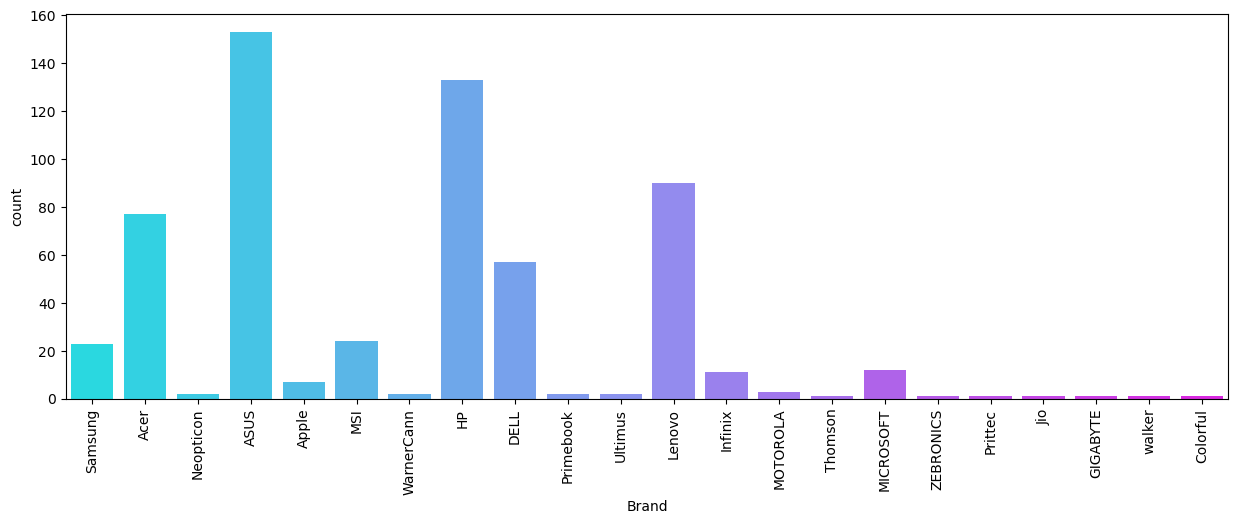

In [72]:
#Brand Distribution
plt.figure(figsize=(15,5))
sns.countplot(x = 'Brand' , data = cleandata ,palette = "cool")
plt.xticks(rotation = 90)  
plt.show()

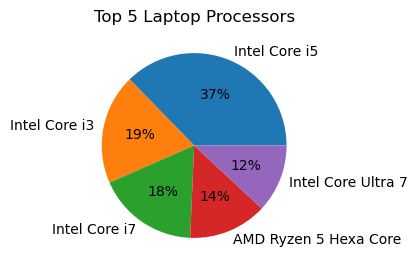

In [73]:
#top 5 processors
processor = cleandata["Processor"].value_counts().head(5)
plt.figure(figsize=(3,3))
plt.pie(processor.values, labels=processor.index, autopct = '%1.0F%%')
plt.title("Top 5 Laptop Processors")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_23280\2948305616.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top5 , x="Brand" , y="Prices" , palette = "Set2" )


Text(0.5, 1.0, 'Top 5 Highest Priced Laptops')

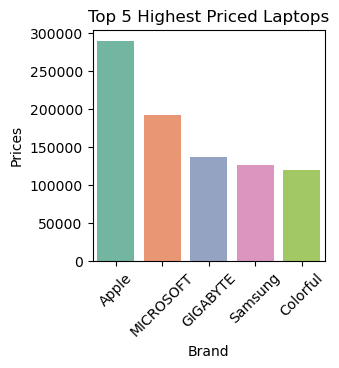

In [74]:
top5 = cleandata.groupby("Brand")["Prices"].mean().sort_values(ascending = False).head(5)
top5 = pd.DataFrame(top5)
plt.figure(figsize=(3,3))
sns.barplot(data = top5 , x="Brand" , y="Prices" , palette = "Set2" )
plt.xticks(rotation=45)
plt.title("Top 5 Highest Priced Laptops")

C:\Users\DELL\AppData\Local\Temp\ipykernel_23280\2801040899.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = cheapest , x="Brand" , y="Prices" , palette = "Set3" )


Text(0.5, 1.0, 'Top 5 Cheapest Laptops')

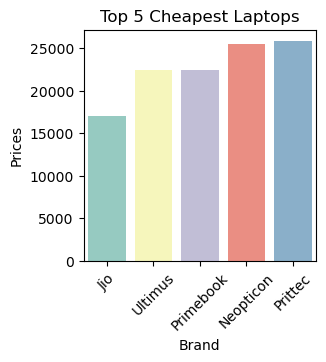

In [75]:
cheapest = cleandata.groupby("Brand")["Prices"].mean().sort_values(ascending = True).head(5)
cheapest = pd.DataFrame(cheapest)
plt.figure(figsize=(3,3))
sns.barplot(data = cheapest , x="Brand" , y="Prices" , palette = "Set3" )
plt.xticks(rotation=45)
plt.title("Top 5 Cheapest Laptops")

In [47]:
print(top5)


                  Prices
Brand                   
Apple      289900.000000
MICROSOFT  192126.916667
GIGABYTE   136990.000000
Samsung    125558.869565
Colorful   119999.000000


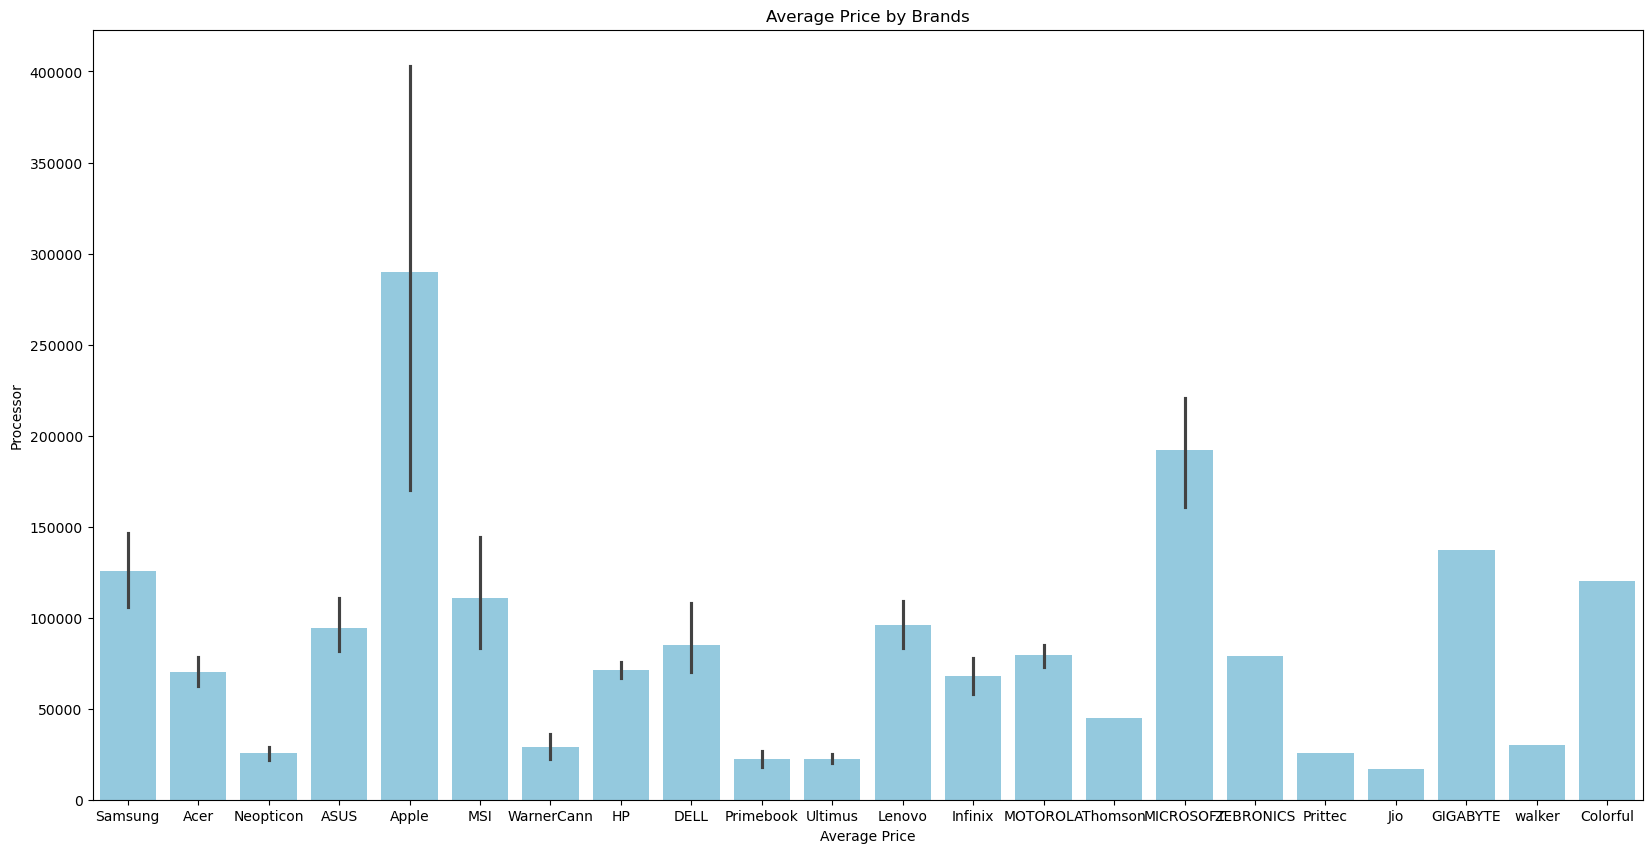

In [51]:
#average price by brand
plt.figure(figsize=(20,10))

sns.barplot(data=cleandata, x="Brand", y="Prices",color = "skyblue")

plt.title("Average Price by Brands")
plt.xlabel("Average Price")
plt.ylabel("Processor")

plt.show()

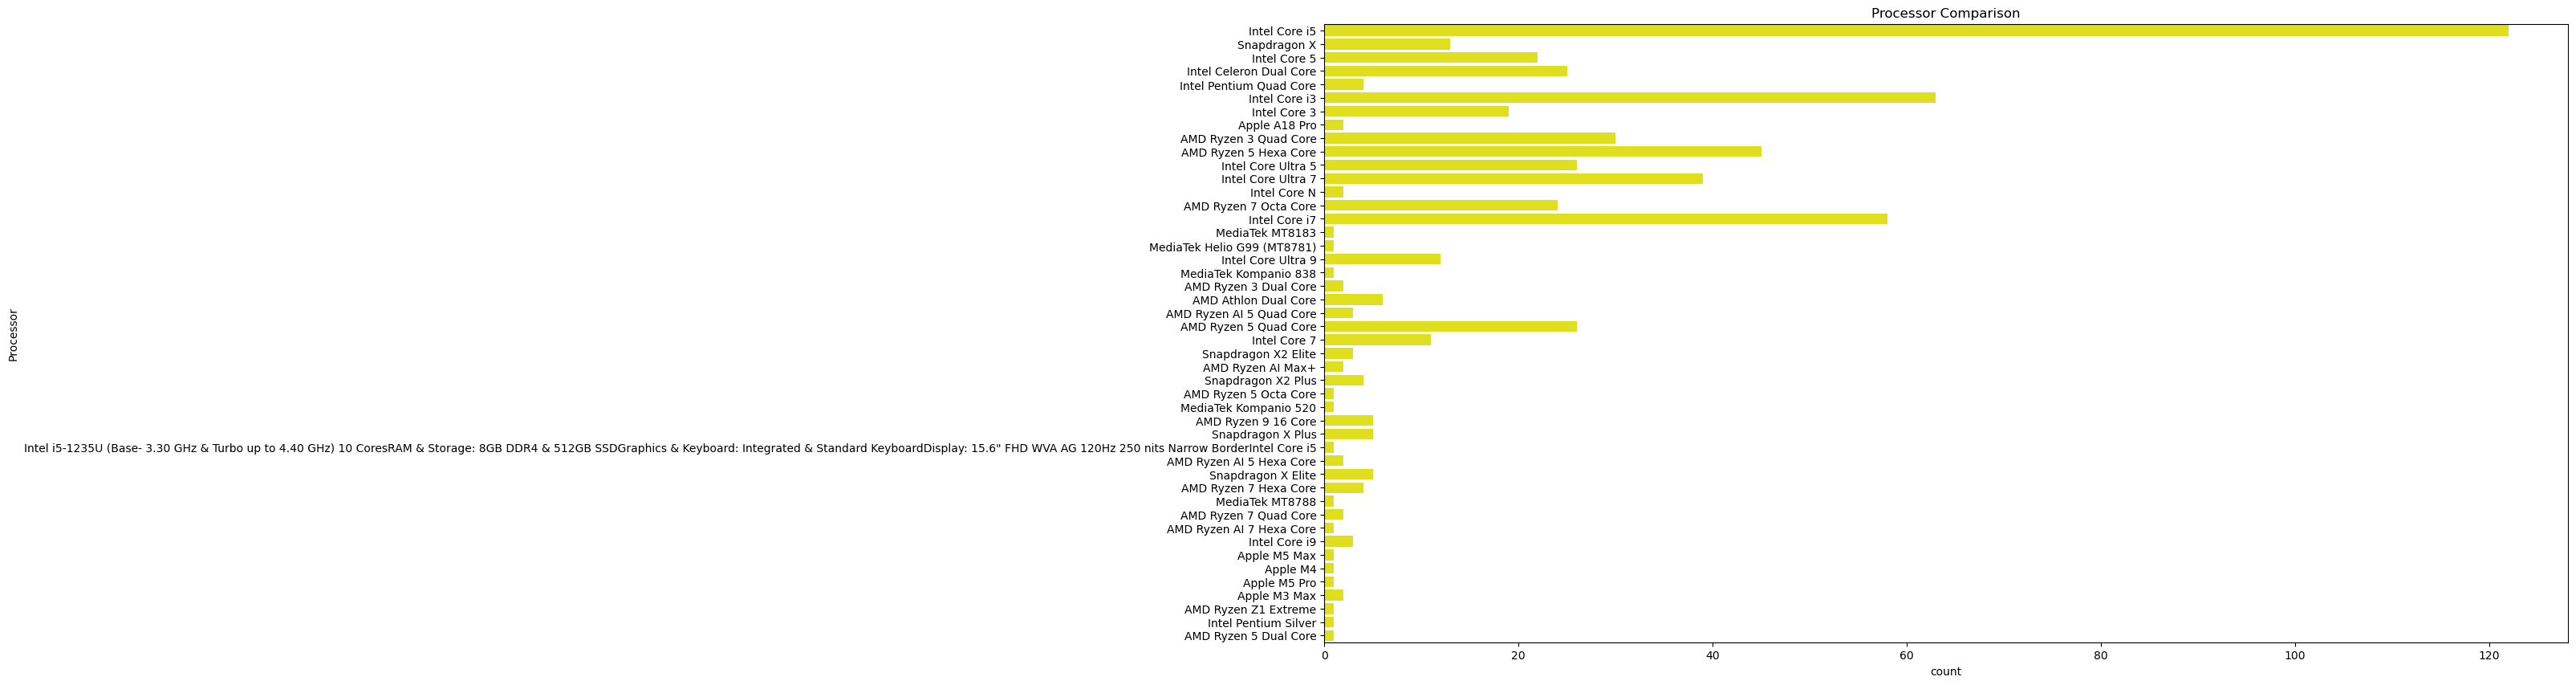

In [52]:
#Processor distributuon
plt.figure(figsize=(20,10))
sns.countplot(cleandata['Processor'],color = "yellow")
plt.title("Processor Comparison")
plt.show()

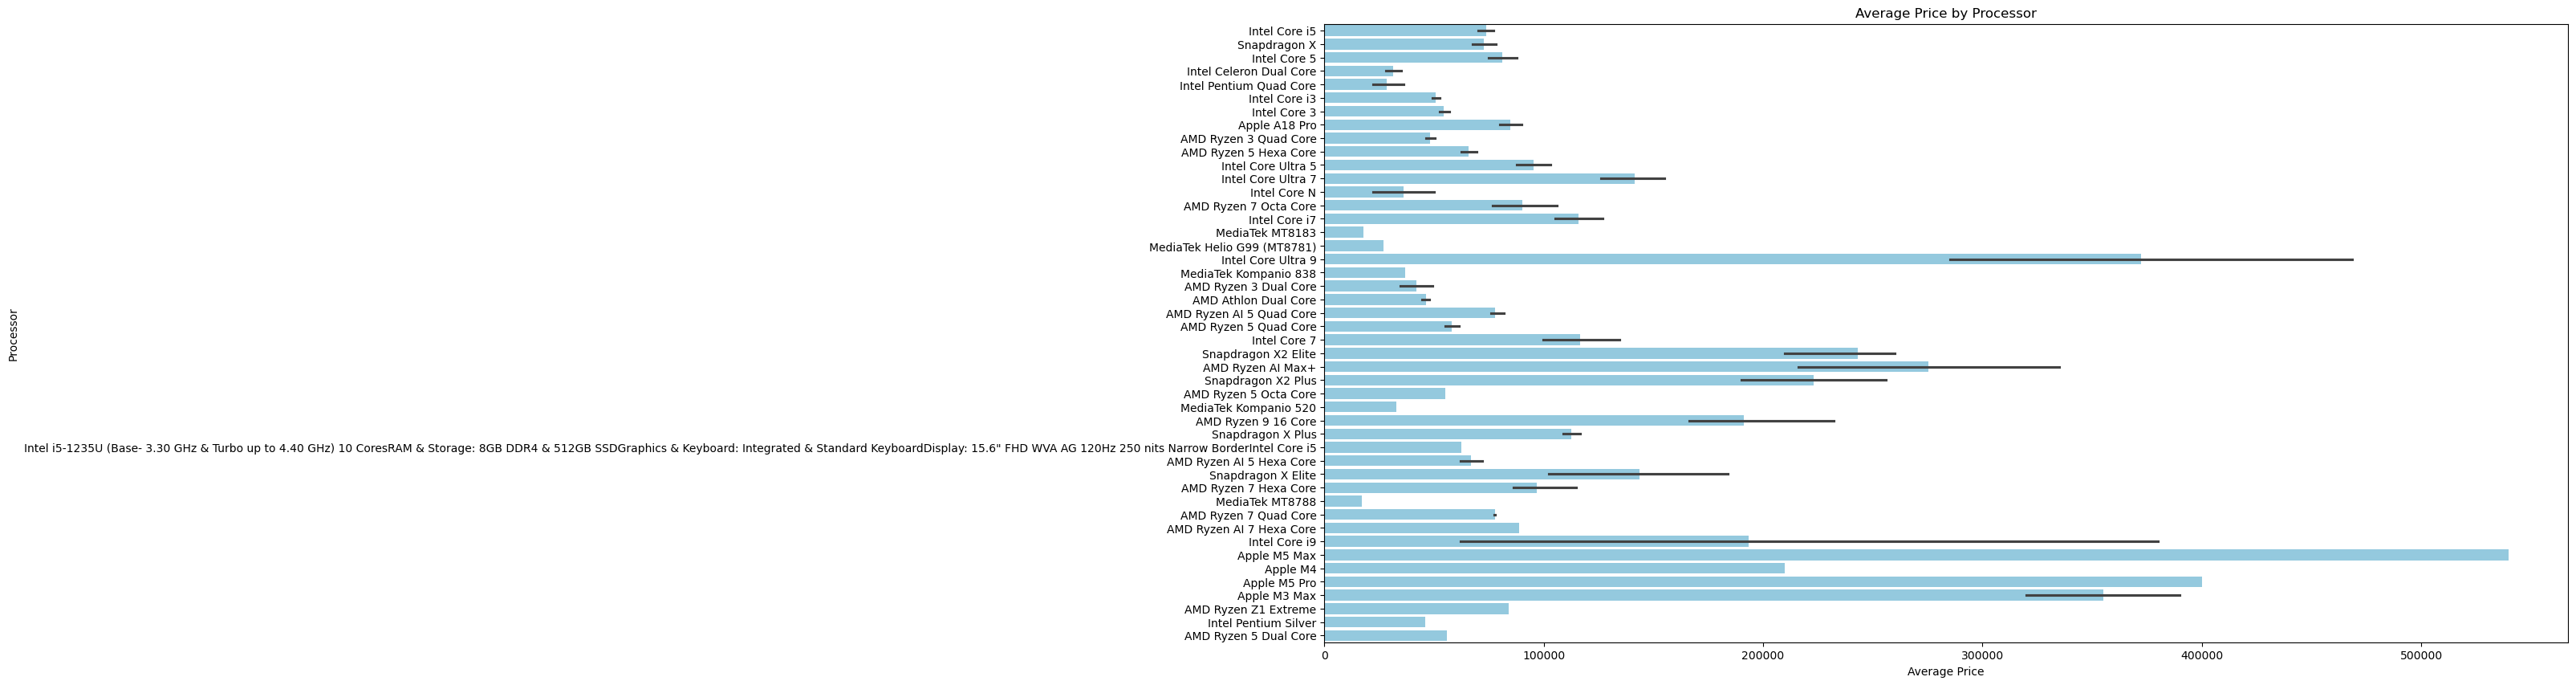

In [53]:
#Average price by processor
plt.figure(figsize=(20,10))

sns.barplot(data=cleandata, y="Processor", x="Prices",color = "skyblue")

plt.title("Average Price by Processor")
plt.xlabel("Average Price")
plt.ylabel("Processor")

plt.show()

<Axes: xlabel='SSD', ylabel='Prices'>

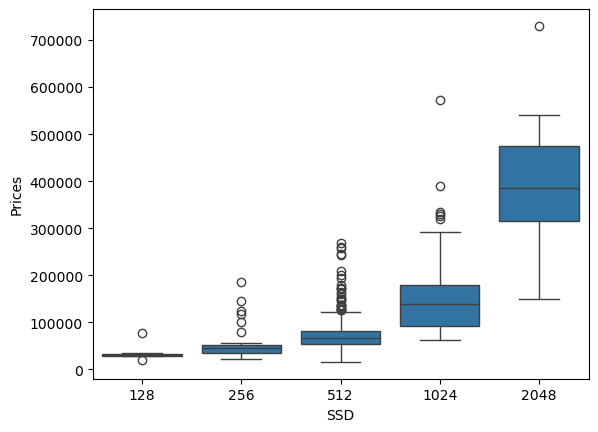

In [54]:
sns.boxplot(data=cleandata , x="SSD" , y="Prices")

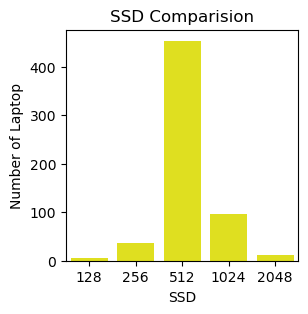

In [55]:
plt.figure(figsize=(3,3))
sns.countplot(x = "SSD" , data=cleandata , color = "yellow")
plt.title("SSD Comparision")
plt.xlabel("SSD")
plt.ylabel("Number of Laptop")
plt.show()

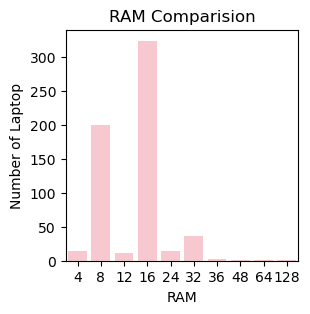

In [56]:
plt.figure(figsize=(3,3))
sns.countplot(x = "RAM" , data=cleandata , color = "pink")
plt.title("RAM Comparision")
plt.xlabel("RAM")
plt.ylabel("Number of Laptop")
plt.show()

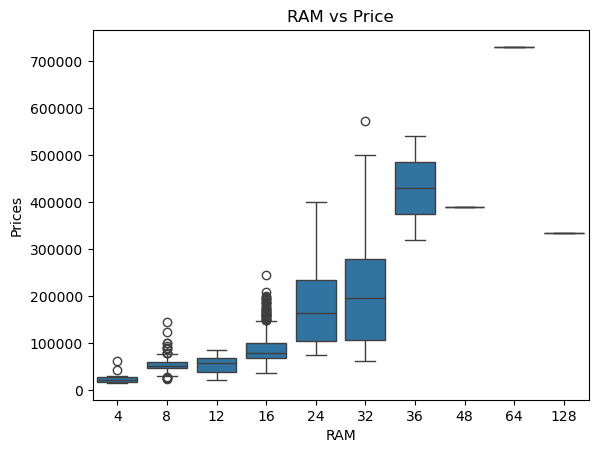

In [57]:
sns.boxplot(data=cleandata, x="RAM", y="Prices")
plt.title("RAM vs Price")
plt.show()

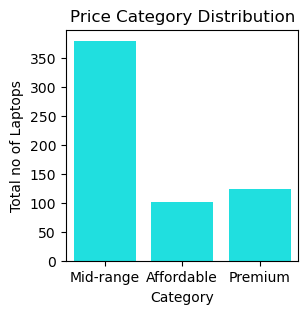

In [58]:
plt.figure(figsize=(3,3))
sns.countplot(data=cleandata, x="PriceCategory" , color = "cyan")
plt.title("Price Category Distribution")
plt.xlabel("Category")
plt.ylabel("Total no of Laptops")
plt.show()

In [76]:
premium = cleandata[cleandata["PriceCategory"] == "Premium"]

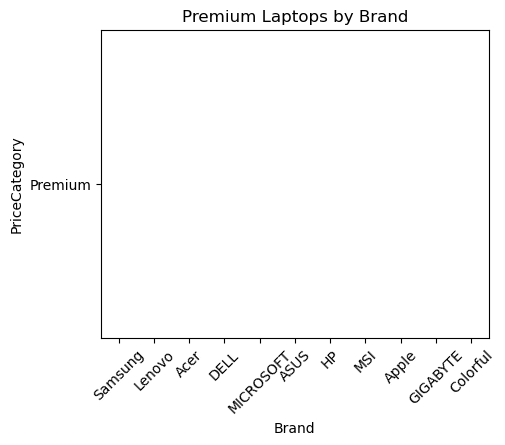

In [81]:
plt.figure(figsize=(5,4))
sns.barplot(data=premium, y="PriceCategory",x="Brand")
plt.xticks(rotation=45)
plt.title("Premium Laptops by Brand")
plt.show()

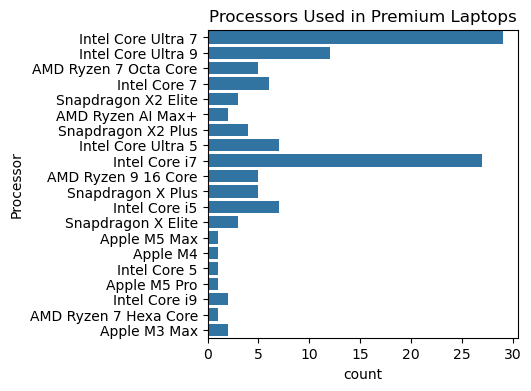

In [64]:
plt.figure(figsize=(4,4))
sns.countplot(data=premium, y="Processor")
plt.title("Processors Used in Premium Laptops")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_23280\2990496305.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cleandata, x="Brand", y="Prices" , palette = "pastel")


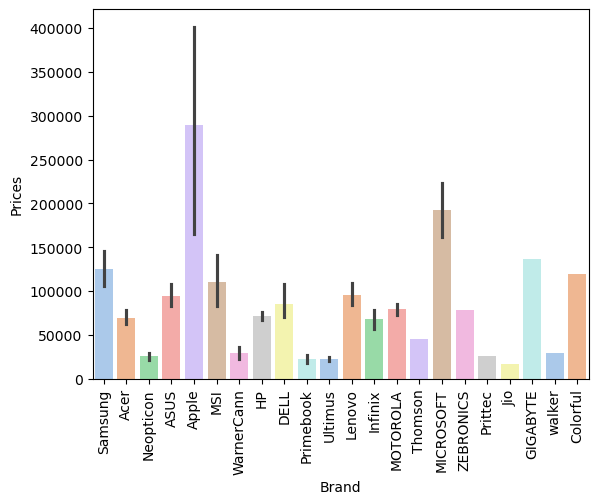

In [65]:
sns.barplot(data=cleandata, x="Brand", y="Prices" , palette = "pastel")

plt.xticks(rotation=90)
plt.show()

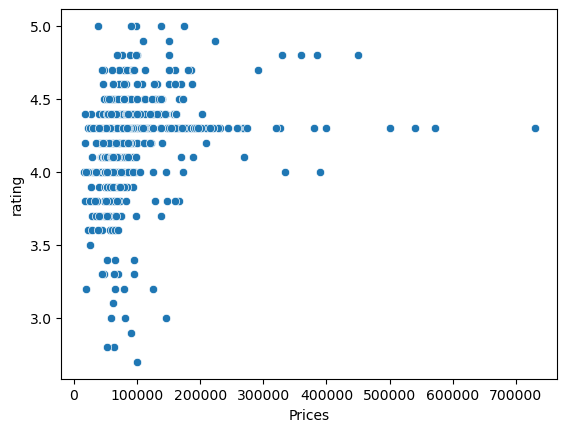

In [66]:
sns.scatterplot(data=cleandata, x="Prices", y="rating")
plt.show()

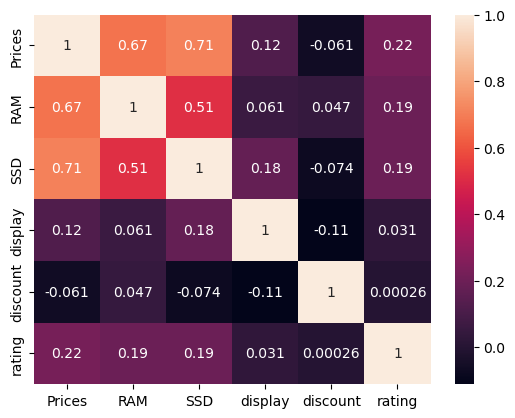

In [67]:
corr = cleandata[["Prices","RAM","SSD","display","discount","rating"]].corr()

sns.heatmap(corr, annot=True)
plt.show()

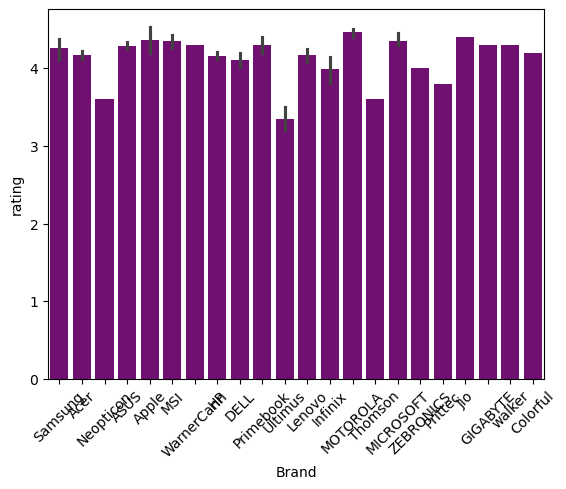

In [68]:
sns.barplot(data=cleandata, x="Brand", y="rating",color = 'purple')
plt.xticks(rotation=45)
plt.show()

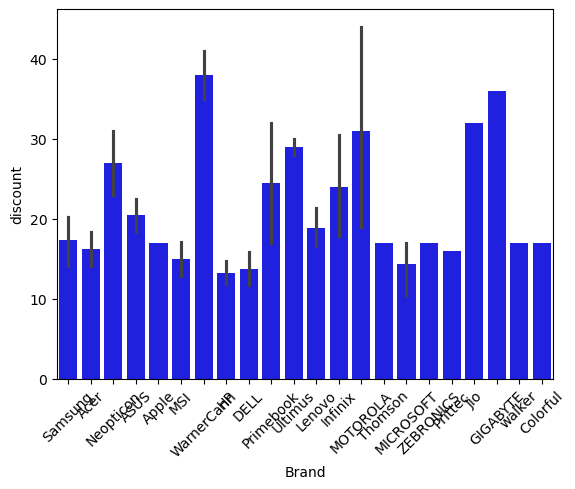

In [69]:
sns.barplot(data=cleandata, x="Brand", y="discount",color = 'blue')

plt.xticks(rotation=45)
plt.show()